In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from itertools import chain

from __future__ import print_function
import ets_fiber_assigner.netflow as nf
from ics.cobraOps.Bench import Bench
from ics.cobraOps.TargetGroup import TargetGroup
from ics.cobraOps.CobrasCalibrationProduct import CobrasCalibrationProduct
from ics.cobraOps.CollisionSimulator import CollisionSimulator
from ics.cobraOps.cobraConstants import NULL_TARGET_POSITION, NULL_TARGET_ID
from ics.cobraOps import plotUtils
from collections import defaultdict
from optimparallel import minimize_parallel

# run netflow

In [2]:
def netflowTest(Pointing,tgt,bench,classdict,t_obs,posang,all_sam,info,nv,gurobiPa):
    Telra=[Pointing[yy] for yy in range(len(Pointing)) if yy%2==0]
    Teldec=[Pointing[yy] for yy in range(len(Pointing)) if yy%2!=0]
    nvisit=nv
    otime = "2016-04-03T08:00:00Z"
    telescopes = []
    
    for kk in range(min(nvisit,len(Telra))):
        telescopes.append(nf.Telescope(Telra[kk], Teldec[kk], posang, otime))
    tpos = [tele.get_fp_positions(tgt) for tele in telescopes]

    # optional: slightly increase the cost for later observations,
    # to observe as early as possible
    vis_cost = [1 for i in range(nvisit)]

    # optional: penalize assignments where the cobra has to move far out
    def cobraMoveCost(dist):
        return 0.1*dist

    gurobiOptions = gurobiPa

    # partially observed? no
    alreadyObserved={}

    # compute observation strategy
    prob = nf.buildProblem(bench, tgt, tpos, classdict, t_obs,
                       vis_cost, cobraMoveCost=cobraMoveCost,
                       collision_distance=2., elbow_collisions=True,
                       gurobi=True, gurobiOptions=gurobiOptions,
                       alreadyObserved=alreadyObserved)

    #print("solving the problem")
    prob.solve()
    Obj=prob._prob.objVal

    # extract solution
    res = [{} for _ in range(min(nvisit,len(Telra)))]
    for k1, v1 in prob._vardict.items():
        if k1.startswith("Tv_Cv_"):
            visited = prob.value(v1) > 0
            if visited:
                _, _, tidx, cidx, ivis = k1.split("_")
                res[int(ivis)][int(tidx)] = int(cidx)

    #print fiber assign
    samping=[0]*17    #sampling rate
    fib_eff=[]        #fiber efficiency
    obj_allo=[]
    for i, (vis, tp, tel) in enumerate(zip(res, tpos, telescopes)):
        #print("exposure {}:".format(i))
        #print("  assigned Cobras: {}".format(len(vis)))
        #print("  assigned Cobras(%): {:.2f}%".format(len(vis)/2394.*100))
        fib_eff.append(len(vis)/2394.*100)
        tdict = defaultdict(int)
        for tidx, cidx in vis.items():
            #print (tidx,cidx)
            tdict[tgt[tidx].targetclass] += 1
            obj_allo.append(tgt[tidx].ID)
        for cls, num in tdict.items():
            if cls=='sci_PA1':samping[0]+=num
            if cls=='sci_PA2':samping[1]+=num
            if cls=='sci_PA3':samping[2]+=num
            if cls=='sci_PA4':samping[3]+=num
            if cls=='sci_PA5':samping[4]+=num
            if cls=='sci_PA6':samping[5]+=num
            if cls=='sci_PA7':samping[6]+=num
            if cls=='sci_PB1':samping[7]+=num
            if cls=='sci_PB2':samping[8]+=num
            if cls=='sci_PB3':samping[9]+=num
            if cls=='sci_PB4':samping[10]+=num
            if cls=='sci_PB5':samping[11]+=num
            if cls=='sci_PB6':samping[12]+=num
            if cls=='sci_PB7':samping[13]+=num
            if cls=='sci_PC1':samping[14]+=num
            if cls=='sci_PC2':samping[15]+=num
            if cls=='cal':
                samping[16]+=num
                print("   {}: {}".format(cls, num))
    saam=np.array(samping)/np.array(all_sam)
    Obj_=sum([(1-saam[uu])*P[uu]*part for uu in range(16)])
    #print(saam)
    return saam,fib_eff,Obj,Obj_#'''   

# define input & classdict

In [3]:
#make runs reproducible
np.random.seed(20)

fscience_targets = "test_data/test_full.dat"
#fcal_stars = "test_data/Fstar_test"

tgt = nf.readScientificFromFile(fscience_targets, "sci")
#tgt += nf.readCalibrationFromFile(fcal_stars, "cal")

# get a complete, idealized focal plane configuration
bench = Bench(layout="full")

# priority for A1-C2
P=[802.4338200210916,709.6070225378721,787.3208877704762,772.0776847688146,\
   769.7736194495538,711.1884660624916,689.5245248805687,77.06557331861154,\
   77.29814856714206,70.54068100072975,79.10576126779472,79.18519799857891,\
   72.07728590873303,69.02870043442842,6.87275284538186,7.745724447644481]
part=10

classdict = {}
classdict["sci_PA7"] = {"nonObservationCost": P[6],
                       "partialObservationCost": P[6]*part, "calib": False}
classdict["sci_PA6"] = {"nonObservationCost": P[5],
                       "partialObservationCost": P[5]*part, "calib": False}
classdict["sci_PA5"] = {"nonObservationCost": P[4],
                       "partialObservationCost": P[4]*part, "calib": False}
classdict["sci_PA4"] = {"nonObservationCost": P[3],
                       "partialObservationCost": P[3]*part, "calib": False}
classdict["sci_PA3"] = {"nonObservationCost": P[2],
                       "partialObservationCost": P[2]*part, "calib": False}
classdict["sci_PA2"] = {"nonObservationCost": P[1],
                       "partialObservationCost": P[1]*part, "calib": False}
classdict["sci_PA1"] = {"nonObservationCost": P[0],
                       "partialObservationCost": P[0]*part, "calib": False}

classdict["sci_PB7"] = {"nonObservationCost": P[6+7],
                       "partialObservationCost": P[6+7]*part, "calib": False}
classdict["sci_PB6"] = {"nonObservationCost": P[5+7],
                       "partialObservationCost": P[5+7]*part, "calib": False}
classdict["sci_PB5"] = {"nonObservationCost": P[4+7],
                       "partialObservationCost": P[4+7]*part, "calib": False}
classdict["sci_PB4"] = {"nonObservationCost": P[3+7],
                       "partialObservationCost": P[3+7]*part, "calib": False}
classdict["sci_PB3"] = {"nonObservationCost": P[2+7],
                       "partialObservationCost": P[2+7]*part, "calib": False}
classdict["sci_PB2"] = {"nonObservationCost": P[1+7],
                       "partialObservationCost": P[1+7]*part, "calib": False}
classdict["sci_PB1"] = {"nonObservationCost": P[0+7],
                       "partialObservationCost": P[0+7]*part, "calib": False}

classdict["sci_PC2"] = {"nonObservationCost": P[15],
                       "partialObservationCost": P[15]*part, "calib": False}
classdict["sci_PC1"] = {"nonObservationCost": P[14],
                       "partialObservationCost": P[14]*part, "calib": False}

#classdict["sky"] = {"numRequired": 100,
#                    "nonObservationCost": 1e6, "calib": True}
classdict["cal"] = {"numRequired": 10,"nonObservationCost": max(P)*100, "calib": True}

all_sam=[len([1 for u in range(len(tgt)) if tgt[u].targetclass==typ]) \
         for typ in ['sci_PA1','sci_PA2','sci_PA3','sci_PA4','sci_PA5','sci_PA6','sci_PA7',\
                    'sci_PB1','sci_PB2','sci_PB3','sci_PB4','sci_PB5','sci_PB6','sci_PB7',\
                    'sci_PC1','sci_PC2','cal']]

# result

In [6]:
%%time
##read in pointing list
test=np.loadtxt('test_data/point_test')
point_con=len(test)

#gurobiPa=dict(seed=0, presolve=1, method=4, degenmoves=0,heuristics=0.8, mipfocus=0, mipgap=1.0e-6,LogToConsole=0)
gurobiPa=dict(seed=0, presolve=1, method=0, degenmoves=0,heuristics=0.6, mipfocus=0, mipgap=1.0e-2)#,LogToConsole=0)

##test with N pointing from the list
output=[]
for point_con in [len(test)]:
    time_start=time.time()
    pointing_test=test[:point_con]
    samp,eff,obj_,obj1_=netflowTest(list(chain.from_iterable(pointing_test)),tgt,bench,classdict,900,0,\
                                all_sam,{'Nfeval':0},point_con,gurobiPa)
    output.append([samp,time.time()-time_start,eff,obj_,obj1_])

Using license file /home/wanqiu/gurobi910/gurobi.lic
Academic license - for non-commercial use only - expires 2022-07-02
Parameter seed unchanged
   Value: 0  Min: 0  Max: 2000000000  Default: 0
Changed value of parameter presolve to 1
   Prev: -1  Min: -1  Max: 2  Default: -1
Changed value of parameter method to 0
   Prev: -1  Min: -1  Max: 5  Default: -1
Changed value of parameter degenmoves to 0
   Prev: -1  Min: -1  Max: 2000000000  Default: -1
Changed value of parameter heuristics to 0.6
   Prev: 0.05  Min: 0.0  Max: 1.0  Default: 0.05
Parameter mipfocus unchanged
   Value: 0  Min: 0  Max: 3  Default: 0
Changed value of parameter mipgap to 0.01
   Prev: 0.0001  Min: 0.0  Max: inf  Default: 0.0001
Creating network topology
  exposure 1
Calculating visibilities
adding constraints
adding collision constraints
  exposure 2
Calculating visibilities
adding constraints
adding collision constraints
  exposure 3
Calculating visibilities
adding constraints
adding collision constraints
  exp

  exposure 87
Calculating visibilities
adding constraints
adding collision constraints
  exposure 88
Calculating visibilities
adding constraints
adding collision constraints
  exposure 89
Calculating visibilities
adding constraints
adding collision constraints
  exposure 90
Calculating visibilities
adding constraints
adding collision constraints
  exposure 91
Calculating visibilities
adding constraints
adding collision constraints
  exposure 92
Calculating visibilities
adding constraints
adding collision constraints
  exposure 93
Calculating visibilities
adding constraints
adding collision constraints
  exposure 94
Calculating visibilities
adding constraints
adding collision constraints
  exposure 95
Calculating visibilities
adding constraints
adding collision constraints
  exposure 96
Calculating visibilities
adding constraints
adding collision constraints
  exposure 97
Calculating visibilities
adding constraints
adding collision constraints
  exposure 98
Calculating visibilities
addi

adding constraints
adding collision constraints
  exposure 181
Calculating visibilities
adding constraints
adding collision constraints
  exposure 182
Calculating visibilities
adding constraints
adding collision constraints
  exposure 183
Calculating visibilities
adding constraints
adding collision constraints
  exposure 184
Calculating visibilities
adding constraints
adding collision constraints
  exposure 185
Calculating visibilities
adding constraints
adding collision constraints
  exposure 186
Calculating visibilities
adding constraints
adding collision constraints
  exposure 187
Calculating visibilities
adding constraints
adding collision constraints
  exposure 188
Calculating visibilities
adding constraints
adding collision constraints
  exposure 189
Calculating visibilities
adding constraints
adding collision constraints
  exposure 190
Calculating visibilities
adding constraints
adding collision constraints
  exposure 191
Calculating visibilities
adding constraints
adding collis

adding constraints
adding collision constraints
  exposure 275
Calculating visibilities
adding constraints
adding collision constraints
  exposure 276
Calculating visibilities
adding constraints
adding collision constraints
  exposure 277
Calculating visibilities
adding constraints
adding collision constraints
  exposure 278
Calculating visibilities
adding constraints
adding collision constraints
  exposure 279
Calculating visibilities
adding constraints
adding collision constraints
  exposure 280
Calculating visibilities
adding constraints
adding collision constraints
  exposure 281
Calculating visibilities
adding constraints
adding collision constraints
  exposure 282
Calculating visibilities
adding constraints
adding collision constraints
  exposure 283
Calculating visibilities
adding constraints
adding collision constraints
  exposure 284
Calculating visibilities
adding constraints
adding collision constraints
  exposure 285
Calculating visibilities
adding constraints
adding collis

adding constraints
adding collision constraints
  exposure 369
Calculating visibilities
adding constraints
adding collision constraints
  exposure 370
Calculating visibilities
adding constraints
adding collision constraints
  exposure 371
Calculating visibilities
adding constraints
adding collision constraints
  exposure 372
Calculating visibilities
adding constraints
adding collision constraints
  exposure 373
Calculating visibilities
adding constraints
adding collision constraints
  exposure 374
Calculating visibilities
adding constraints
adding collision constraints
  exposure 375
Calculating visibilities
adding constraints
adding collision constraints
  exposure 376
Calculating visibilities
adding constraints
adding collision constraints
  exposure 377
Calculating visibilities
adding constraints
adding collision constraints
  exposure 378
Calculating visibilities
adding constraints
adding collision constraints
  exposure 379
Calculating visibilities
adding constraints
adding collis

...

adding constraints
adding collision constraints
  exposure 651
Calculating visibilities
adding constraints
adding collision constraints
  exposure 652
Calculating visibilities
adding constraints
adding collision constraints
  exposure 653
Calculating visibilities
adding constraints
adding collision constraints
  exposure 654
Calculating visibilities
adding constraints
adding collision constraints
  exposure 655
Calculating visibilities
adding constraints
adding collision constraints
  exposure 656
Calculating visibilities
adding constraints
adding collision constraints
  exposure 657
Calculating visibilities
adding constraints
adding collision constraints
  exposure 658
Calculating visibilities
adding constraints
adding collision constraints
  exposure 659
Calculating visibilities
adding constraints
adding collision constraints
  exposure 660
Calculating visibilities
adding constraints
adding collision constraints
  exposure 661
Calculating visibilities
adding constraints
adding collis

adding constraints
adding collision constraints
  exposure 745
Calculating visibilities
adding constraints
adding collision constraints
  exposure 746
Calculating visibilities
adding constraints
adding collision constraints
  exposure 747
Calculating visibilities
adding constraints
adding collision constraints
  exposure 748
Calculating visibilities
adding constraints
adding collision constraints
  exposure 749
Calculating visibilities
adding constraints
adding collision constraints
  exposure 750
Calculating visibilities
adding constraints
adding collision constraints
  exposure 751
Calculating visibilities
adding constraints
adding collision constraints
  exposure 752
Calculating visibilities
adding constraints
adding collision constraints
  exposure 753
Calculating visibilities
adding constraints
adding collision constraints
  exposure 754
Calculating visibilities
adding constraints
adding collision constraints
  exposure 755
Calculating visibilities
adding constraints
adding collis

adding constraints
adding collision constraints
  exposure 839
Calculating visibilities
adding constraints
adding collision constraints
  exposure 840
Calculating visibilities
adding constraints
adding collision constraints
  exposure 841
Calculating visibilities
adding constraints
adding collision constraints
  exposure 842
Calculating visibilities
adding constraints
adding collision constraints
  exposure 843
Calculating visibilities
adding constraints
adding collision constraints
  exposure 844
Calculating visibilities
adding constraints
adding collision constraints
  exposure 845
Calculating visibilities
adding constraints
adding collision constraints
  exposure 846
Calculating visibilities
adding constraints
adding collision constraints
  exposure 847
Calculating visibilities
adding constraints
adding collision constraints
  exposure 848
Calculating visibilities
adding constraints
adding collision constraints
  exposure 849
Calculating visibilities
adding constraints
adding collis

adding constraints
adding collision constraints
  exposure 933
Calculating visibilities
adding constraints
adding collision constraints
  exposure 934
Calculating visibilities
adding constraints
adding collision constraints
  exposure 935
Calculating visibilities
adding constraints
adding collision constraints
  exposure 936
Calculating visibilities
adding constraints
adding collision constraints
  exposure 937
Calculating visibilities
adding constraints
adding collision constraints
  exposure 938
Calculating visibilities
adding constraints
adding collision constraints
  exposure 939
Calculating visibilities
adding constraints
adding collision constraints
  exposure 940
Calculating visibilities
adding constraints
adding collision constraints
  exposure 941
Calculating visibilities
adding constraints
adding collision constraints
  exposure 942
Calculating visibilities
adding constraints
adding collision constraints
  exposure 943
Calculating visibilities
adding constraints
adding collis

<ipython-input-2-9ad627efb317>:80: RuntimeWarning: invalid value encountered in true_divide
  saam=np.array(samping)/np.array(all_sam)


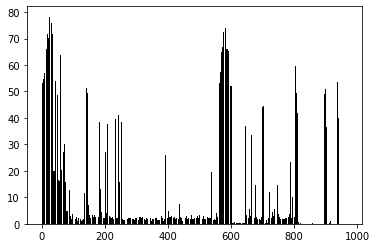

In [13]:
#fiber allocation efficiency of individual pointing
plt.bar(np.arange(1,len(output[0][-3])+1,1),output[0][-3],width=0.8,fc='k',ec='none')
plt.show()